<a href="https://colab.research.google.com/github/dazzens/dazzens/blob/main/EDA_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

------------------
---------
-----

# **Пет проект EDA (исследовательский анализ данных).**




Автор: А.Г.Х.

Начало: 22.06.2026


Окончание: --.--.2026

----



##**Бизнес-контекст**

- Интернет-магазин продает товары для дома и декора по всему миру. За последний год ассортимент вырос на 30%, но темпы роста выручки замедлились. Необходимо исследовать данные о продажах, чтобы понять, какие товары и страны приносят основную прибыль, кто самые ценные клиенты и как оптимизировать ценовую политику.

-----

# **Цель исследования**

- Выявить ключевые факторы, влияющие на динамику продаж интернет-магазина, для разработки рекомендаций по увеличению выручки и удержанию клиентов.


##**Вопросы:**


- 1. Как менялись продажи по месяцам? Динамика выручки, количества заказов и сезонность.

- 2. Какие товары самые популярные? Топ по количеству продаж, топ по выручке, топ по частоте заказов.

- 3. Какой средний чек и размер корзины? Среднее количество товаров в заказе, средняя сумма заказа

- 4. Какие страны приносят больше всего выручки? Топ по выручке, топ по количеству заказов, топ по среднему чеку

- 5. Кто самые прибыльные клиенты? Топ клиентов по сумме трат, по частоте покупок, анализ повторных покупок

- 6. Как цена влияет на продажи? Распределение цен, зависимость количества продаж от цены, оптимальные ценовые сегменты

- 7. Какие товары, страны и клиентские сегменты вносят наибольший вклад в выручку?


## **Содержание проекта**



1.  **Первичный осмотр и подготовка данных**
    *   Импорт библиотек и загрузка данных.
    *   Предварительный анализ структуры данных (типы, объем, пропуски).
    *   Преобразование типов данных (`Date` в `datetime`, `CustomerNo` в `int`).
    *   Проверка и обработка пропусков (`CustomerNo`).
    *   Проверка дубликатов и выбросов (`Price`, `Quantity`).

2.  **Предварительный анализ и создание новых признаков**
    *   Расчет общих метрик (общая выручка, количество заказов, количество клиентов, средний чек).
    *   Создание признаков: месяц, день недели, год из даты.
    *   Создание признака: общая сумма заказа (`Price` x `Quantity`).
    *   Агрегация данных на уровне заказа (`TransactionNo`) для анализа корзины.

3.  **Исследовательский анализ данных (EDA)**
    *   Анализ динамики продаж: выручка и количество заказов по месяцам, сезонность.
    *   Анализ товаров: топ-10 по выручке, топ-10 по количеству продаж, распределение цен.
    *   Анализ корзины: среднее количество товаров в заказе, средний чек, распределение заказов по сумме.
    *   Анализ клиентов: топ-10 по сумме трат, топ-10 по частоте покупок, новые, повторные клиенты.
    *   Географический анализ: выручка и количество заказов по странам, средний чек по странам.
    *   Анализ ценовых сегментов: зависимость количества продаж от цены.

4.  **Ключевые выводы и рекомендации**
    *   Формирование основных инсайтов по каждому блоку анализа.
    *   Разработка практических рекомендаций для увеличения выручки, удержания клиентов и оптимизации ассортимента.


    

## **Описание данных**

**Транзакционные данные (онлайн-магазин):**

| | | |
|------|----------|------------|
| `TransactionNo` | Уникальный идентификатор транзакции/заказа | `object` |
| `Date` | Дата совершения покупки | `object` |
| `ProductNo` | Уникальный идентификатор товара | `object` |
| `ProductName` | Название товара | `object` |
| `Price` | Цена за единицу товара | `float64` |
| `Quantity` | Количество единиц товара в заказе | `int64` |
| `CustomerNo` | Уникальный идентификатор клиента | `float64` |
| `Country` | Страна клиента | `object` |

---

**Характеристики данных:**

|  |  |
|------------|----------|
| **Объем данных** | 536 350 записей |
| **Количество клиентов** | 4 738 |
| **Количество уникальных товаров** | 3 768 |
| **Количество стран** | 38 |
| **Пропуски** | 55 записей без `CustomerNo` (0.01%) |



----
----

# **Этап 1 Первичный осмотр и подготовка данных**

- Импорт библиотек и загрузка данных.
- Предварительный анализ структуры данных (типы, объем, пропуски).
- Преобразование типов данных (`Date` в `datetime`, `CustomerNo` в `int`).
- Проверка и обработка пропусков (`CustomerNo`).
- Проверка дубликатов и выбросов (`Price`, `Quantity`).



## **Шаг 1. Загрузка данных**

- Импорт библиотек и загрузка датасета из внешнего источника.

---
### **Библиотеки**




In [1]:
#загруза библиотек

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import kagglehub
    import os
    print("Все библиотеки загружены")

except ImportError:
    !pip install numpy pandas matplotlib seaborn   kagglehub -q
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import kagglehub
    import os
    print("Библиотеки загружены через pip")



Все библиотеки загружены


### **Загрузка датасета**

In [2]:
#Загрузка датасета
path = kagglehub.dataset_download("gabrielramos87/an-online-shop-business")
file_path = os.path.join(path, [x for x in os.listdir(path) if x.endswith('.csv')][0])

#Сохранение
df = pd.read_csv(file_path)



100%|██████████| 6.66M/6.66M [00:00<00:00, 9.19MB/s]

Extracting files...


**Итого:**

 - Установлены необходимые библиотеки и датасет сохранён в `df`

-----
----
----

## **Шаг 2. Общий осмотр данных**

Первичный анализ структуры данных включает оценку следующих параметров, таких как:

- размерность датасета
- типы признаков и их соответствие содержанию
- наличие пропусков и их доля в каждом поле
- основные статистические характеристики числовых переменных

In [3]:
# Основная информация
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [4]:
#Вывод первых 10 строк
df.head(10)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
5,581475,12/9/2019,21705,Bag 500g Swirly Marbles,10.65,24,13069.0,United Kingdom
6,581475,12/9/2019,22118,Joy Wooden Block Letters,11.53,18,13069.0,United Kingdom
7,581475,12/9/2019,22119,Peace Wooden Block Letters,12.25,12,13069.0,United Kingdom
8,581475,12/9/2019,22217,T-Light Holder Hanging Lace,10.65,12,13069.0,United Kingdom
9,581475,12/9/2019,22216,T-Light Holder White Lace,10.55,24,13069.0,United Kingdom


In [5]:
#Осмотр случайных строк
df.sample(10)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
175456,568702,9/28/2019,23079,Toadstool Bedside Light,19.42,1,17950.0,United Kingdom
443061,544206,2/17/2019,22946,Wooden Advent Calendar Cream,44.37,1,14206.0,United Kingdom
121465,572913,10/26/2019,85071C,"Charlie+Lola""Extremely Busy"" Sign",10.65,5,15993.0,United Kingdom
535014,536544,12/1/2018,20658,Red Retrospot Luggage Tag,12.82,1,17544.0,United Kingdom
480786,541088,1/13/2019,21533,Retrospot Large Milk Jug,15.32,3,15513.0,United Kingdom
5755,581439,12/8/2019,22197,Popcorn Holder,6.19,70,15439.0,United Kingdom
413477,547000,3/18/2019,22996,Travel Card Wallet Vintage Ticket,10.68,24,14282.0,United Kingdom
520276,537622,12/7/2018,84388,Wise Man Star Shape Egg Pan,11.94,1,13173.0,United Kingdom
239900,563181,8/12/2019,21931,Jumbo Storage Bag Suki,12.38,10,16612.0,United Kingdom
324805,555539,6/5/2019,22227,Hanging Heart Mirror Decoration,10.92,3,14472.0,United Kingdom


In [6]:
#Осмотр по различным показателям
df.describe()


,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


### **Результаты первичного осмотра**

**Общая информация:**
- Датасет содержит 536 350 записей, 8 столбцов.
- Пропуски: в поле `CustomerNo`.
- Типы данных: `Date` и `CustomerNo` требуют преобразования для дальнейшего анализа.
- `Price`: среднее — 12.66 руб., медиана — 11.94 руб. Диапазон: от 5.13 до 660.62 руб.
- `Quantity`: среднее — 9.92 шт., медиана — 3 шт. Диапазон: от -80 995 до 80 995 шт., что указывает на наличие экстремальных значений.
  
**Выводы:**
  
  -  Данные содержат аномалии в `Quantity` (отрицательные и экстремально высокие значения) и выбросы в `Price`.
  - Требуется преобразование типов и принятие решения по обработке аномалий. В остальном данные пригодны для анализа.
  - Требуется осомотр пропусков в поле `CustomerNo`.


## **Шаг 3. Обработка типов данных**

- проверка и приведение типов данных к форматам, соответствующим их содержанию
- обеспечение согласованности типов для последующих операций
- оптимизация структуры данных для дальнейшей работы
- `Date` преобразовать в `datetime` для временной аналитики
- `CustomerNo` привести  к `Int64` для корректной группировки клиентов

In [7]:
#Осмотр типов данных

df.dtypes

,0
TransactionNo,object
Date,object
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,float64
Country,object


In [8]:
# преобразование данных
df['Date'] = pd.to_datetime(df['Date'])
df['CustomerNo'] = df['CustomerNo'].astype('Int64')

#проверка
df.dtypes

,0
TransactionNo,object
Date,datetime64[ns]
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,Int64
Country,object


### **Итог преобразования**

Типы данных приведены к форматам, необходимым для дальнейшего анализа

- `Date` преобразована в `datetime`, что открывает доступ к исследованию временных рядов и сезонных срезов;
- `CustomerNo` переведён в `Int64` с поддержкой пропусков, что обеспечивает корректную идентификацию клиентов при группировках.

Остальные типы данных оставлены без изменений.

---
----

## **Шаг 4. Поиск и обработка пропусков**

- Проверка данных на наличие пропущенных значений
- оценка их объема
- анализ возможного влияния на результаты исследования и принятие
- решения по их обработке

In [9]:
# колличесвто и доля пропусков

df.isnull().sum(), df.isnull().mean()

(TransactionNo     0
 Date              0
 ProductNo         0
 ProductName       0
 Price             0
 Quantity          0
 CustomerNo       55
 Country           0
 dtype: int64,
 TransactionNo    0.000000
 Date             0.000000
 ProductNo        0.000000
 ProductName      0.000000
 Price            0.000000
 Quantity         0.000000
 CustomerNo       0.000103
 Country          0.000000
 dtype: float64)

In [10]:
# отображение данных

df[df['CustomerNo'].isnull()].head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,<NA>,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,<NA>,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,<NA>,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,<NA>,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,<NA>,United Kingdom
163160,C569495,2019-10-04,21843,Red Retrospot Cake Stand,21.47,-1,<NA>,United Kingdom
190598,C567518,2019-09-20,22846,Bread Bin Diner Style Red,27.62,-1,<NA>,United Kingdom
192284,C567518,2019-09-20,21871,Save The Planet Mug,11.94,-12,<NA>,United Kingdom
242406,C563015,2019-08-11,46000M,Polyester Filler Pad 45x45cm,10.25,-160,<NA>,United Kingdom
242407,C563015,2019-08-11,46000S,Polyester Filler Pad 40x40cm,10.25,-220,<NA>,United Kingdom


####**Описание и дальнейшие действия:**

* Пропуски обнаружены только в поле `CustomerNo` и составляют **55** записей (0.01%).
* Для сохранения всех наблюдений пропуски будут заменены значением `-1`, которое в дальнейшем будет обозначать неизвестного клиента

----

In [11]:
# Замена NaN на специальное значение
df['CustomerNo'] = df['CustomerNo'].fillna(-1)

# проверка после заполнения пропусков
display(df[df['CustomerNo'] == -1].head(10))

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,-1,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,-1,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,-1,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,-1,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,-1,United Kingdom
163160,C569495,2019-10-04,21843,Red Retrospot Cake Stand,21.47,-1,-1,United Kingdom
190598,C567518,2019-09-20,22846,Bread Bin Diner Style Red,27.62,-1,-1,United Kingdom
192284,C567518,2019-09-20,21871,Save The Planet Mug,11.94,-12,-1,United Kingdom
242406,C563015,2019-08-11,46000M,Polyester Filler Pad 45x45cm,10.25,-160,-1,United Kingdom
242407,C563015,2019-08-11,46000S,Polyester Filler Pad 40x40cm,10.25,-220,-1,United Kingdom


### **Итог работы c пропусками:**


Пропуски в `CustomerNo` обработаны заменой на значение `-1`.


Пропущенных значений в датасете не осталось.



---
---

## **Шаг 5. Поиск и анализ  явных/неявных дубликатов**

- Выявление избыточных записей (полностью совпадающих строк)

- оценка их объёма и доли в общем массиве данных

- анализ возможного влияния дубликатов на агрегированные метрики

- принятие решения по обработке: удаление или агрегация

---

###**Анализ явных дубликатов:**

- поиск полностью совпадающих строк по всем колонкам
- оценка количества и доли дубликатов в данных
- анализ влияния на метрики (выручка, количество заказов, товаров)


In [12]:
# Количество и доля явных дубликатов

duplicates_count = df.duplicated().sum()
duplicates_percent = (duplicates_count / len(df)) * 100

print(f"Количество дубликатов: {duplicates_count}")
print(f"Процент дубликатов: {duplicates_percent:.2f}%")

Количество дубликатов: 5200
Процент дубликатов: 0.97%


In [13]:
#Вывод записей дубликатов

df[df.duplicated()].head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
985,581497,2019-12-09,21481,Fawn Blue Hot Water Bottle,7.24,1,17497,United Kingdom
1365,581538,2019-12-09,23275,Set Of 3 Hanging Owls Ollie Beak,6.19,1,14446,United Kingdom
1401,581538,2019-12-09,22992,Revolver Wooden Ruler,6.19,1,14446,United Kingdom
1406,581538,2019-12-09,22694,Wicker Star,6.19,1,14446,United Kingdom
1409,581538,2019-12-09,23343,Jumbo Bag Vintage Christmas,6.19,1,14446,United Kingdom
3255,581237,2019-12-08,23498,Classic Bicycle Clips,6.19,1,15443,United Kingdom
3259,581237,2019-12-08,23497,Classic Chrome Bicycle Bell,6.19,1,15443,United Kingdom
3261,581237,2019-12-08,23509,Mini Playing Cards Fun Fair,6.19,2,15443,United Kingdom
3284,581237,2019-12-08,23378,Pack Of 12 50'S Christmas Tissues,6.19,1,15443,United Kingdom
3593,581253,2019-12-08,23427,Stool Home Sweet Home,6.19,1,16891,United Kingdom


####**Дальнейшие действия с явными дубликатами:**


Обнаружено **5200** дубликатов (0.97% от всех записей).  

Удаление не повлияет на общую структуру данных и исключит искажение метрик.

In [14]:
#Удаление дубликатов и проверка

df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

####**Итоги обработки:**

Явные дубликаты полностью удалены.

 В датасете не осталось полностью совпадающих строк.


----
-----

### **Анализ неявных дубликатов:**

- Проверка наличия повторяющихся товаров в рамках одной транзакции.
- Оценка доли неявных дубликатов.
- Анализ структуры повторяющихся записей.
- Проверка возможности их объединения без потери информации.
- Выбор и обоснование обработки.

In [15]:
# Поиск неявных дубликатов

implicit_duplicates = (
    df.groupby(['TransactionNo', 'ProductNo'])
      .size()
      .reset_index(name='count')
      .query('count > 1')
)

display(implicit_duplicates.head(10))

print(f'Найдено комбинаций с повторяющимися товарами: {len(implicit_duplicates)}')



,TransactionNo,ProductNo,count
133,536381,71270,2
515,536409,85116,2
518,536409,90199C,3
529,536412,21448,2
535,536412,21738,3
538,536412,22077,3
541,536412,22144,2
545,536412,22243,3
547,536412,22273,2
562,536412,22749,2


Найдено комбинаций с повторяющимися товарами: 5553


In [16]:
# Строки, относящиеся к найденным комбинациям

duplicate_rows = df.merge(
    implicit_duplicates[['TransactionNo', 'ProductNo']],
    on=['TransactionNo', 'ProductNo']
)

print(f'Количество строк с повторами: {len(duplicate_rows)}')
print(f'Доля строк от общего объема данных: {len(duplicate_rows) / len(df) * 100:.2f}%')

Количество строк с повторами: 11336
Доля строк от общего объема данных: 2.13%


In [17]:
# Пример одной транзакции с повторяющимися товарами

sample_transaction = implicit_duplicates['TransactionNo'].iat[0]

display(
    df.loc[
        df['TransactionNo'] == sample_transaction,
        ['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity']
    ].sort_values('ProductNo')
)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity
533393,536381,2018-12-01,15056N,Edwardian Parasol Natural,16.35,2
533379,536381,2018-12-01,21166,Cook With Wine Metal Sign,12.25,1
533378,536381,2018-12-01,21169,You're Confusing Me Metal Sign,11.98,3
533380,536381,2018-12-01,21175,Gin And Tonic Diet Metal Sign,12.40,2
533400,536381,2018-12-01,21523,Doormat Fancy Font Home Sweet Home,17.17,10
533391,536381,2018-12-01,21533,Retrospot Large Milk Jug,15.32,1
533392,536381,2018-12-01,21557,Set Of 6 Funky Beakers,13.27,2
533371,536381,2018-12-01,21672,White Spot Red Ceramic Drawer Knob,11.53,6
533397,536381,2018-12-01,21731,Red Toadstool Led Night Light,11.94,2
533377,536381,2018-12-01,21934,Skull Shoulder Bag,11.94,10


---
Также, для точности, необходимо будет:

- проверить корректность объединения данных

- убедиться, что повторяющиеся товары не имеют разницу по цене

In [18]:
price_check = (
    duplicate_rows
    .groupby(['TransactionNo', 'ProductNo'])
    .agg(unique_prices=('Price', 'nunique'))
    .query('unique_prices > 1')
)

print(f'Комбинаций с разными ценами: {len(price_check)}')

display(price_check.head())

Комбинаций с разными ценами: 1033


unique_prices
TransactionNo ProductNo               
536544        21218                  2
              22844                  2
              22862                  2
              22866                  2
536592        22165                  2

####**Рузультаты проверки и дальнейшие действия**

 В ходе проверки обнаружены две комбинации `TransactionNo` и `ProductNo`, в которых один и тот же товар имеет разные значения `Price`.

Объединение  по `TransactionNo` и `ProductNo` может привести к потере информации, это стоит учитывать
и поле `Price` включается в группировку.


---

 Отрицательные значения `Quantity `на данный момент не изменяются.

 Отрицательные значения `Quantity`  участвуют в объединении наравне с остальными записями, поскольку отражают отдельный тип операций (например, возвраты) и будут исследоваться далее отдельно.


 ---

Для сохранения данных,  позиции будут объединены по  `Quantity.`

Группировка выполняется по:

- `TransactionNo`
- `Date`
- `ProductNo`
- `ProductName`
- `Price`
- `CustomerNo`
- `Country`

In [19]:
# Объединение неявных дубликатов

df = (
    df.groupby(
        [
            'TransactionNo',
            'Date',
            'ProductNo',
            'ProductName',
            'Price',
            'CustomerNo',
            'Country'
        ],
        as_index=False
    )['Quantity']
    .sum()
)

print(f'Размер датафрейма после объединения: {df.shape}')

display(df.head())

Размер датафрейма после объединения: (526417, 8)


,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
0,536365,2018-12-01,21730,Glass Star Frosted T-Light Holder,14.61,17850,United Kingdom,6
1,536365,2018-12-01,22752,Set 7 Babushka Nesting Boxes,18.09,17850,United Kingdom,2
2,536365,2018-12-01,71053,White Moroccan Metal Lantern,13.72,17850,United Kingdom,6
3,536365,2018-12-01,84029E,Red Woolly Hottie White Heart,13.72,17850,United Kingdom,6
4,536365,2018-12-01,84029G,Knitted Union Flag Hot Water Bottle,13.72,17850,United Kingdom,6


In [20]:
remaining_duplicates = (
    df.groupby(['TransactionNo', 'ProductNo', 'Price'])
      .size()
      .gt(1)
      .sum()
)

print(f'Оставшихся неявных дубликатов: {remaining_duplicates}')

Оставшихся неявных дубликатов: 0


####**Итоги обработки**

- Неявные дубликаты успешно объединены.

- Повторяющиеся позиции одного товара внутри одной транзакции сведены в одну запись путем суммирования `Quantity.`

- Использование `Price` в ключе группировки позволило избежать объединения записей с различной стоимостью товара.

- Проверка показала, что после обработки неявные дубликаты отсутствуют.

- Датафрейм готов к дальнейшему исследованию.

-----
----
---

##**Шаг 6. Детальный анализ особенностей данных**

Выявление аномалий, особенностей распределений и скрытых закономерностей, которые могут повлиять на дальнейший анализ.

В рамках данного шага будут рассмотрены:
- распределение `Price`
-  распределение `Quantity` (включая отрицательные значения)
- исследование выбросов и длинных хвостов  
- анализ уникальных значений  
- поиск дополнительных закономерностей и аномалий



###**Анализ распределение `Price`**


Ранее при первом знакомстве с признаком `Price` были изучены общие статистические характеристики.

На данном шаге, подробнее рассмотрим особенности распределения цен, а также проверим природу анамальных высоких значений.




In [21]:
df['Price'].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

,Price
0.25,11.02
0.50,11.94
0.75,14.09
0.90,17.90
0.95,19.61
0.99,27.30


Большинство товаров имеет стоимость менее 27.30, однако для оценки наличия длинного правого хвоста рассмотрим количество наблюдений, превышающих 99-й перцентиль.

In [22]:
q99 = df['Price'].quantile(0.99)

print(df[df['Price'] > q99].shape[0])

4469


Полученные результаты свидетельствуют о наличии относительно небольшой группы товаров с существенно более высокой стоимостью. Для понимания природы этих наблюдений рассмотрим наиболее дорогие товары.

In [23]:
top_expensive_products = (
    df[['ProductName', 'Price']]
    .drop_duplicates()
    .sort_values(by='Price', ascending=False)
    .head(15)
)

top_expensive_products

,ProductName,Price
27486,Vintage Blue Kitchen Cabinet,660.62
4744,Vintage Red Kitchen Cabinet,660.62
80360,Vintage Red Kitchen Cabinet,594.50
130068,Vintage Blue Kitchen Cabinet,594.50
105952,Love Seat Antique White Metal,210.12
23930,Love Seat Antique White Metal,189.62
238,Rustic Seventeen Drawer Sideboard,179.37
18504,Regency Mirror With Shutters,179.37
18503,Rustic Seventeen Drawer Sideboard,158.88
83700,Regency Mirror With Shutters,158.88


Среди наиболее дорогих товаров встречаются одинаковые наименования с различными значениями цены. На данном этапе это рассматривается как особенность данных. Причины различий (изменение цен во времени, особенности продаж или другие факторы) будут исследованы на последующих этапах анализа.

####**Краткий вывод**

Анализ показал, что распределение Price имеет выраженный длинный правый хвост. Несмотря на то что основная часть товаров имеет стоимость ниже 99-го перцентиля (27.30), в данных присутствует небольшое количество значительно более дорогих товаров.

На текущем этапе признаков, позволяющих считать эти значения ошибками, не обнаружено, поэтому они сохраняются для дальнейшего анализа.

----
---
---

###**Анализ отрицательных  и аномальных значений Quantity**

- исследование структуры отклонений в количестве товаров;
- интерпретация отрицательных значений как возвратов;
- оценка объёма и доли аномалий;
- анализ распределения по транзакциям;
- принятие решения по обработке.






####**Отрицательное значение Quantity**

In [24]:
# Просмотр первых записей с отрицательным количеством
display( df[df["Quantity"] < 0] .sort_values(by="Quantity") .head(15) )

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
526411,C581484,2019-12-09,23843,Paper Craft Little Birdie,6.19,16446,United Kingdom,-80995
518850,C541433,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,-74215
517930,C536757,2018-12-02,84347,Rotating Silver Angels T-Light Hldr,10.28,15838,United Kingdom,-9360
520587,C550456,2019-04-18,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,-3114
520588,C550456,2019-04-18,21175,Gin And Tonic Diet Metal Sign,12.15,15749,United Kingdom,-2000
520591,C550456,2019-04-18,85123A,Cream Hanging Heart T-Light Holder,12.86,15749,United Kingdom,-1930
521571,C556522,2019-06-13,22920,Herb Marker Basil,10.81,16938,United Kingdom,-1515
520589,C550456,2019-04-18,47566B,Tea Time Party Bunting,12.86,15749,United Kingdom,-1300
524452,C570556,2019-10-11,20971,Pink Blue Felt Craft Trinket Box,11.34,16029,United Kingdom,-1296
524014,C569552,2019-10-04,15034,Paper Pocket Traveling Fan,10.32,14533,United Kingdom,-1200


In [25]:
# Количество и доля отрицательных значений

negative_quantity_count = df[df["Quantity"] < 0].shape[0]
negative_quantity_share = negative_quantity_count / df.shape[0] * 100

print(f"Количество записей: {negative_quantity_count}")
print(f"Доля записей: {negative_quantity_share:.2f}%")

Количество записей: 8519
Доля записей: 1.62%


In [26]:

#Проверка записей  начинаются транзакций с "C"

(
  df.loc[df["Quantity"] < 0, "TransactionNo"]
  .astype("string")
  .str.startswith("C", na=False)
  .value_counts()
  )

,count
TransactionNo,
True,8519


In [27]:
#Поиск отрицательных значений без префикса "C"

negative_without_c = df[
    (df["Quantity"] < 0)
    & (
        df["TransactionNo"]
        .astype("string")
        .str.startswith("C", na=False) == False
    )
]

print(
    "Количество отрицательных записей без префикса C:",
    negative_without_c.shape[0]
)



Количество отрицательных записей без префикса C: 0


In [28]:
# Сохранение возвратов в отдельный датафрейм
returns_df = df[df["Quantity"] < 0].copy()

#Cоздание датафрейма с состоявшимися продажами
sales_df = df[df["Quantity"] > 0].copy()

----

#### **Аномальные значения Quantity**


In [29]:
#Создание датафрейма с положительными значениями Quantity

positive_quantity_df = df[df["Quantity"] > 0].copy()

print(
    "Количество записей с положительным Quantity:",
    positive_quantity_df.shape[0]
)

Количество записей с положительным Quantity: 517898


In [30]:
#Квантили положительных значений
sales_df["Quantity"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

,Quantity
0.25,1.0
0.50,4.0
0.75,12.0
0.90,24.0
0.95,30.0
0.99,100.0


In [31]:
# Определение 99-го перцентиля
quantity_q99 = positive_quantity_df["Quantity"].quantile(0.99)

print(f"99-й перцентиль Quantity: {quantity_q99}")

99-й перцентиль Quantity: 100.0


In [32]:
#Выделение наблюдений выше 99-го перцентиля

high_quantity_df = positive_quantity_df[
    positive_quantity_df["Quantity"] > quantity_q99
].copy()

print(
    "Количество наблюдений выше 99-го перцентиля:",
    high_quantity_df.shape[0]
)

Количество наблюдений выше 99-го перцентиля: 4852


In [33]:
# Просмотр наблюдений с наибольшим количеством товара

largest_quantity_rows = (
    positive_quantity_df
    .sort_values(
        by="Quantity",
        ascending=False
    )
    .head(15)
)

display(largest_quantity_rows)

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
516441,581483,2019-12-09,23843,Paper Craft Little Birdie,12.38,16446,United Kingdom,80995
58955,541431,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,74215
479617,578841,2019-11-25,84826,Asstd Design 3d Paper Stickers,6.19,13256,United Kingdom,12540
403126,573008,2019-10-27,84077,World War 2 Gliders Asstd Designs,10.47,12901,United Kingdom,4800
197065,554868,2019-05-27,22197,Popcorn Holder,10.99,13135,United Kingdom,4300
92989,544612,2019-02-22,22053,Empire Design Rosette,11.09,18087,United Kingdom,3906
259099,560599,2019-07-19,18007,Essential Balm 35g Tin In Envelope,10.31,14609,United Kingdom,3186
50323,540815,2019-01-11,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
153278,550461,2019-04-18,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
414686,573995,2019-11-02,16014,Small Chinese Style Scissor,10.58,16308,United Kingdom,3000


In [34]:
# Получение номеров соответствующих транзакций

largest_transaction_numbers = (
    largest_quantity_rows["TransactionNo"]
    .dropna()
    .unique()
)

display(largest_transaction_numbers)

array(['581483', '541431', '578841', '573008', '554868', '544612',
       '560599', '540815', '550461', '573995', '562439', '536830',
       '554272', '543057', '543669'], dtype=object)

In [35]:
#Просмотр всех позиций найденных транзакций

largest_quantity_transactions = (
    positive_quantity_df[
        positive_quantity_df["TransactionNo"].isin(
            largest_transaction_numbers
        )
    ]
    .sort_values(
        by=["TransactionNo", "Quantity"],
        ascending=[True, False]
    )
)

display(largest_quantity_transactions)

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
4701,536830,2018-12-02,84077,World War 2 Gliders Asstd Designs,10.43,16754,United Kingdom,2880
4700,536830,2018-12-02,21915,Red Harmonica In Box,11.34,16754,United Kingdom,1400
50323,540815,2019-01-11,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
50324,540815,2019-01-11,21175,Gin And Tonic Diet Metal Sign,12.15,15749,United Kingdom,2000
50325,540815,2019-01-11,85123A,Cream Hanging Heart T-Light Holder,12.86,15749,United Kingdom,1930
58955,541431,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,74215
77098,543057,2019-02-03,84077,World War 2 Gliders Asstd Designs,10.47,16333,United Kingdom,2592
77097,543057,2019-02-03,21915,Red Harmonica In Box,11.34,16333,United Kingdom,420
83689,543669,2019-02-11,22693,Grow A Flytrap Or Sunflower In Tin,11.21,16029,United Kingdom,2400
92989,544612,2019-02-22,22053,Empire Design Rosette,11.09,18087,United Kingdom,3906


#### **Краткий вывод**


- В ходе анализа установлено, что отрицательные значения `Quantity` составляют **1,62%** от общего числа наблюдений. Все такие записи относятся к транзакциям с префиксом `C`, что подтверждает их связь с возвратами или отменёнными операциями. Для последующего анализа продаж данные записи выделены в отдельный датафрейм.

- Анализ положительных значений показал, что **99-й перцентиль** распределения `Quantity` составляет **100 единиц**, а выше этого значения находится **4 852 наблюдения**. Просмотр крупнейших значений и соответствующих транзакций не выявил очевидных признаков ошибок: большинство экстремальных значений являются частью реальных крупных заказов.

- На данном этапе основания для удаления высоких значений `Quantity` отсутствуют. Возвраты исключены из анализа продаж, а положительные экстремальные значения сохранены для дальнейшего исследования.

----
----
---

## **Осмотр уникальных позиций**

- анализ количества уникальных значений в полях с категориальными данными;
- проверка корректности и согласованности значений;
- выявление редких или нестандартных позиций, требующих внимания.

### **Исследование ассортимента**

- Общая характеристика категориальных признаков
- Есть ли один код товара с разными названиями
- Есть ли одинаковые названия товаров с разными кодами
- Какие товары продаются чаще всего
- Какие товары почти никогда не встречаются

In [36]:
categorical_columns = [
    "TransactionNo",
    "ProductNo",
    "ProductName",
    "CustomerNo",
    "Country"
]

df[categorical_columns].nunique().sort_values(ascending=False)

,0
TransactionNo,23204
CustomerNo,4739
ProductNo,3768
ProductName,3768
Country,38


In [37]:
(
    df.groupby("ProductNo")["ProductName"]
      .nunique()
      .sort_values(ascending=False)
      .head(20)
)

,ProductName
ProductNo,
90214Z,1
10002,1
10080,1
10120,1
10123C,1
10124A,1
10124G,1
10125,1
90214H,1


In [38]:
(
    df.groupby("ProductName")["ProductNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(20)
)

,ProductNo
ProductName,
Zinc Wire Sweetheart Letter Tray,1
10 Colour Spaceboy Pen,1
12 Coloured Party Balloons,1
12 Daisy Pegs In Wood Box,1
12 Egg House Painted Wood,1
12 Hanging Eggs Hand Painted,1
12 Ivory Rose Peg Place Settings,1
12 Message Cards With Envelopes,1
Zinc Heart Lattice Charger Large,1


In [39]:
(
    df["ProductName"]
      .value_counts()
      .head(20)
)

,count
ProductName,
Cream Hanging Heart T-Light Holder,2320
Regency Cakestand 3 Tier,2179
Jumbo Bag Red Retrospot,2139
Party Bunting,1710
Lunch Bag Red Retrospot,1611
Assorted Colour Bird Ornament,1468
Set Of 3 Cake Tins Pantry Design,1459
Popcorn Holder,1445
Pack Of 72 Retrospot Cake Cases,1343


In [40]:
rare_products = (
    df["ProductName"]
      .value_counts()
)

rare_products[rare_products == 1]

,count
ProductName,
"Letter ""U"" Bling Key Ring",1
Porcelain Hanging Bell Small,1
Cream Sweetheart Shelf + Hooks,1
Woolly Hat Sock Glove Advent String,1
Tea Time Cake Stand In Gift Box,1
...,...
Set 10 Cards Christmas Bauble 16954,1
Light Decoration Battery Operated,1
Ruby Glass Cluster Necklace,1


### **Исследование поведения покупателей и товаров**

- Есть ли клиенты с одной покупкой
- Есть ли товары, которые покупает только один клиент
- Есть ли товары, которые присутствуют почти в каждой корзине

In [41]:
customer_orders = (
    df.groupby("CustomerNo")["TransactionNo"]
      .nunique()
)

customer_orders.describe()

,TransactionNo
count,4739.000000
mean,4.896392
std,8.810156
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,241.000000


In [42]:
(
    df.groupby("ProductName")["CustomerNo"]
      .nunique()
      .sort_values()
      .head(20)
)

,CustomerNo
ProductName,
Fire Polished Glass Neckl Gold,1
Wrap Pink Flock,1
White With Metal Bag Charm,1
M/Colour Pom-Pom Curtain,1
Pink Dolly Hair Clips,1
Flower Shop Design Mug,1
Pink Crystal Guitar Phone Charm,1
Pink Flock Photo Frame,1
Pink Baroque Flock Candle Holder,1


In [43]:
(
    df.groupby("ProductName")["TransactionNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(20)
)

,TransactionNo
ProductName,
Cream Hanging Heart T-Light Holder,2311
Regency Cakestand 3 Tier,2169
Jumbo Bag Red Retrospot,2135
Party Bunting,1706
Lunch Bag Red Retrospot,1608
Assorted Colour Bird Ornament,1467
Set Of 3 Cake Tins Pantry Design,1458
Popcorn Holder,1442
Pack Of 72 Retrospot Cake Cases,1334


### **География продаж**

- Какие страны реально участвуют в продажах
- Какие товары продаются во многих странах

In [44]:
(
    df["Country"]
      .value_counts()
)

,count
Country,
United Kingdom,475370
Germany,10641
France,10488
EIRE,8014
Belgium,2538
Spain,2415
Netherlands,2330
Switzerland,2329
Portugal,1827


In [45]:
(
    df["Country"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

,proportion
Country,
United Kingdom,90.30
Germany,2.02
France,1.99
EIRE,1.52
Belgium,0.48
Spain,0.46
Netherlands,0.44
Switzerland,0.44
Portugal,0.35


In [46]:
(
    df.groupby("ProductName")["Country"]
      .nunique()
      .sort_values(ascending=False)
      .head(20)
)

,Country
ProductName,
Regency Cakestand 3 Tier,31
Jam Making Set With Jars,26
Baking Set 9 Piece Retrospot,26
Jam Making Set Printed,25
Set Of 3 Cake Tins Pantry Design,25
Set Of 3 Regency Cake Tins,24
Set Of 4 Knick Knack Tins Doily,24
Plasters In Tin Woodland Animals,23
Set Of 4 Pantry Jelly Moulds,23


---
---
---

##**Выводы по первому этапу**


- **Явные дубликаты** были удалены: 5 200 записей (0,97%), искажающие статистику.

- **Неявные дубликаты** (11 336 записей) были агрегированы. Это был способ формирования корзины. Клиент добавлял товар частями. Объединение таких позиций сохранило данные и дало корректную структуру заказа.

- **Отрицательное `Quantity`** — 8 519 записей (1,62%) были выделены в отдельный датафрейм. Это возвраты, подтверждённые префиксом `C` в номере транзакции. Сохранили данные  для отдельного анализа причин возвратов.


- **Аномалии по цене и количеству**  исследованы и были выявлены как  премиальные товары и оптовые заказы.

---
**Итого:**

Записи в количестве **526 417**, без пропусков и дубликатов. Данные структурированы, классифицированы, возвраты выделены. Датасет подготовлен для дальнейшего анализа.

**Точки роста**


- Добавить количество клиентов и товаров после очистки.

- Добавить диапазон дат для понимания временного охвата.

- Упомянуть, что возвраты выделены для отдельного анализа.

- Нет проверки на Price = 0	Могли быть бесплатные товары	Проверить и добавить (покупка за 0 тоже покупка)

- Нет проверки выбросов в CustomerNo	ID клиентов теоретически могут содержать аномалии (например, -1 после замены пропусков)	Проверить, что CustomerNo не содержит других аномалий

- Объединение неявных дубликатов с разными ценами	В 1033 комбинациях один товар имел разную цену. Мы объединили их, но с разными ценами это могло исказить средний чек	В будущем можно анализировать отдельно: "Почему у одного товара в одном заказе разные цены?"

- Дисбаланс по странам	90,3% продаж — Великобритания. Анализ других стран может быть статистически ненадёжным	При анализе по странам выделить UK отдельно, а остальные объединить в "другие"


----
----
----

#**Этап 2. Предварительный анализ и создание новых признаков**

 На данном этапе  готовим данные для углублённого анализа:

- создание  новых признаков
- агрегация данных на уровне заказа
- рассчет  ключевых метрик

## **Шаг 2.1. Создание новых признаков**

- Извлечение признаков из даты
из колонки `Date` - год, месяц и день недели для анализа сезонности и временных трендов.

- Создание признака общей суммы заказа. Создание признака `TotalAmount` = `Price` × `Quantity` для расчёта выручки.

---

In [47]:

# Извлечение различных временных признаков

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayOfWeekName'] = df['Date'].dt.day_name()


# Проверка
print(df[['Date',
          'Year',
          'Month',
          'DayOfWeek',
          'DayOfWeekName']].head())


        Date  Year  Month  DayOfWeek DayOfWeekName
0 2018-12-01  2018     12          5      Saturday
1 2018-12-01  2018     12          5      Saturday
2 2018-12-01  2018     12          5      Saturday
3 2018-12-01  2018     12          5      Saturday
4 2018-12-01  2018     12          5      Saturday


In [48]:
# Создание признака TotalAmount

df['TotalAmount'] = df['Price'] * df['Quantity']

print(df[['Price', 'Quantity', 'TotalAmount']].head())

   Price  Quantity  TotalAmount
0  14.61         6        87.66
1  18.09         2        36.18
2  13.72         6        82.32
3  13.72         6        82.32
4  13.72         6        82.32


In [49]:
# Проверка признаков

print(f"Year: {df['Year'].min()} – {df['Year'].max()}")
print(f"Month: {df['Month'].min()} – {df['Month'].max()}")
print(f"DayOfWeek: {df['DayOfWeek'].min()} – {df['DayOfWeek'].max()}")
print(f"TotalAmount: {df['TotalAmount'].min():.2f} – {df['TotalAmount'].max():.2f}")


display(df[['Date',
            'Year',
            'Month',
            'DayOfWeek',
            'Price',
            'Quantity',
            'TotalAmount']].head(10))


Year: 2018 – 2019
Month: 1 – 12
DayOfWeek: 0 – 6
TotalAmount: -840113.80 – 1002718.10


,Date,Year,Month,DayOfWeek,Price,Quantity,TotalAmount
0,2018-12-01,2018,12,5,14.61,6,87.66
1,2018-12-01,2018,12,5,18.09,2,36.18
2,2018-12-01,2018,12,5,13.72,6,82.32
3,2018-12-01,2018,12,5,13.72,6,82.32
4,2018-12-01,2018,12,5,13.72,6,82.32
5,2018-12-01,2018,12,5,13.07,8,104.56
6,2018-12-01,2018,12,5,12.86,6,77.16
7,2018-12-01,2018,12,5,12.15,6,72.90
8,2018-12-01,2018,12,5,12.15,6,72.90
9,2018-12-01,2018,12,5,16.35,3,49.05


Из колонки `Date` извлечены признаки: `Year`, `Month`, `DayOfWeek`, `DayOfWeekName`.  
Создан признак `TotalAmount` = `Price` × `Quantity` для расчёта выручки.

Диапазон значений:
- `Year`: 2018–2019
- `Month`: 1–12
- `DayOfWeek`: 0–6 (понедельник – воскресенье)
- `TotalAmount`: от -840 113.80 до 1 002 718.10

Отрицательные значения в `TotalAmount` связаны с возвратами (отрицательное `Quantity`), что будет учтено на следующих этапах анализа.

Данные готовы к агрегации и расчёту метрик.

## **Шаг 2.2. Агрегация данных на уровне заказа**

Данные группируются по `TransactionNo` для анализа корзины:

- общая сумма заказа,  

- общее количество товаров,

- уникальные товары в заказе.

---

In [50]:
# Объединение признаков

order_agg = df.groupby('TransactionNo').agg(
    total_amount=('TotalAmount', 'sum'), # общая сумма заказа,
    total_quantity=('Quantity', 'sum'), # общее количество товаров,
    unique_products=('ProductNo', 'nunique'), #уникальные товары в заказе

    # дополнительные группировки
    customer_no=('CustomerNo', 'first'),
    country=('Country', 'first'),
    date=('Date', 'first'),
    month=('Month', 'first'),
    year=('Year', 'first'),
    day_of_week=('DayOfWeek', 'first')
).reset_index()

print(f"Агрегировано заказов: {len(order_agg)}")

display(order_agg.head(10))

Агрегировано заказов: 23204


,TransactionNo,total_amount,total_quantity,unique_products,customer_no,country,date,month,year,day_of_week
0,536365,552.52,40,7,17850,United Kingdom,2018-12-01,12,2018,5
1,536366,145.80,12,2,17850,United Kingdom,2018-12-01,12,2018,5
2,536367,1136.34,83,12,13047,United Kingdom,2018-12-01,12,2018,5
3,536368,225.54,15,4,13047,United Kingdom,2018-12-01,12,2018,5
4,536369,49.05,3,1,13047,United Kingdom,2018-12-01,12,2018,5
5,536370,5393.02,446,19,12583,France,2018-12-01,12,2018,5
6,536371,1028.80,80,1,13748,United Kingdom,2018-12-01,12,2018,5
7,536372,145.80,12,2,17850,United Kingdom,2018-12-01,12,2018,5
8,536373,1168.28,88,16,17850,United Kingdom,2018-12-01,12,2018,5
9,536374,687.04,32,1,15100,United Kingdom,2018-12-01,12,2018,5


Выполнена агрегация данных на уровне заказа.

Получена таблица `order_agg`, содержащая 23 204 заказа.

Для каждого заказа рассчитаны:
- `total_amount` — общая сумма
- `total_quantity` — общее количество товаров
- `unique_products` — количество уникальных товаров в заказе

Дополнительно добавлены:
- `customer_no`, `country`, `date`, `month`, `year`, `day_of_week` для дальнейшего анализа клиентов, географии и временных срезов.

---

## **Шаг 2.3. Расчёт общих метрик**

- Общая выручка
- Количество заказов
- Количество клиентов
- Средний чек
- Средний размер корзины

---

In [51]:

# Расчёт общих метрик

#Общая выручка
total_revenue = order_agg['total_amount'].sum()
print(f"Общая выручка: {total_revenue:,.2f} руб.")


# Количество заказов
total_orders = len(order_agg)
print(f"Всего заказов: {total_orders:,}")


# Количество клиентов
total_customers = order_agg['customer_no'].nunique()
print(f"Всего клиентов: {total_customers:,}")

# Средний чек с медианой
avg_check = order_agg['total_amount'].mean()
median_check = order_agg['total_amount'].median()

print(f"Средний чек: {avg_check:,.2f} руб.")
print(f"Медианный чек: {median_check:,.2f} руб.")

# Средний размер корзины  с медианой
avg_basket = order_agg['total_quantity'].mean()
median_basket = order_agg['total_quantity'].median()


print(f"Средний размер корзины: {avg_basket:,.2f} шт.")
print(f"Медианный размер корзины: {median_basket:,.2f} шт.")


Общая выручка: 60,116,758.39 руб.
Всего заказов: 23,204
Всего клиентов: 4,739
Средний чек: 2,590.79 руб.
Медианный чек: 1,377.59 руб.
Средний размер корзины: 228.64 шт.
Медианный размер корзины: 120.00 шт.


- Общая выручка составила **60,1 млн руб.** при **23 204 заказах** от **4 739 клиентов**.
- Средний чек — **2 590,79 руб.**, медианный — **1 377,59 руб.** (разница указывает на влияние крупных заказов).
- Средний размер корзины — **228,64 шт.**, медианный — **120 шт.**, что подтверждает наличие как мелких, так и крупных оптовых заказов.

----

## **Шаг 2.4. Анализ товаров**

- Топ-10 товаров по выручке
- Топ-10 товаров по количеству продаж
- Распределение цен на товары

---

In [52]:
print('=' * 60)
print('ТОП-10 ТОВАРОВ ПО ВЫРУЧКЕ')
print('=' * 60)

top_10_revenue = df.groupby('ProductName')['TotalAmount'].sum().nlargest(10)
display(top_10_revenue.reset_index())



ТОП-10 ТОВАРОВ ПО ВЫРУЧКЕ


,ProductName,TotalAmount
0,Popcorn Holder,583075.23
1,World War 2 Gliders Asstd Designs,556157.63
2,Paper Craft Little Birdie,501359.05
3,Cream Hanging Heart T-Light Holder,451163.73
4,Assorted Colour Bird Ornament,419557.68
5,Pack Of 72 Retrospot Cake Cases,388180.66
6,Rabbit Night Light,327293.83
7,Jumbo Bag Red Retrospot,289853.95
8,Regency Cakestand 3 Tier,288752.33
9,Mini Paint Set Vintage,284870.92


In [53]:
print('\n' + '=' * 60)
print('ТОП-10 ТОВАРОВ ПО КОЛИЧЕСТВУ ПРОДАЖ')
print('=' * 60)

top_10_quantity = df.groupby('ProductName')['Quantity'].sum().nlargest(10)
display(top_10_quantity.reset_index())


ТОП-10 ТОВАРОВ ПО КОЛИЧЕСТВУ ПРОДАЖ


,ProductName,Quantity
0,Popcorn Holder,56431
1,World War 2 Gliders Asstd Designs,53751
2,Jumbo Bag Red Retrospot,47260
3,Assorted Colour Bird Ornament,36346
4,Pack Of 72 Retrospot Cake Cases,36208
5,Cream Hanging Heart T-Light Holder,35359
6,Rabbit Night Light,30634
7,Mini Paint Set Vintage,26437
8,Pack Of 12 London Tissues,25891
9,Pack Of 60 Pink Paisley Cake Cases,24719


In [54]:
print('\n' + '=' * 60)
print('РАСПРЕДЕЛЕНИЕ ЦЕН НА ТОВАРЫ')
print('=' * 60)

# Описательные статистики для цен
display(df['Price'].describe())



РАСПРЕДЕЛЕНИЕ ЦЕН НА ТОВАРЫ


,Price
count,526417.000000
mean,12.682536
std,8.559146
min,5.130000
25%,11.020000
50%,11.940000
75%,14.090000
max,660.620000


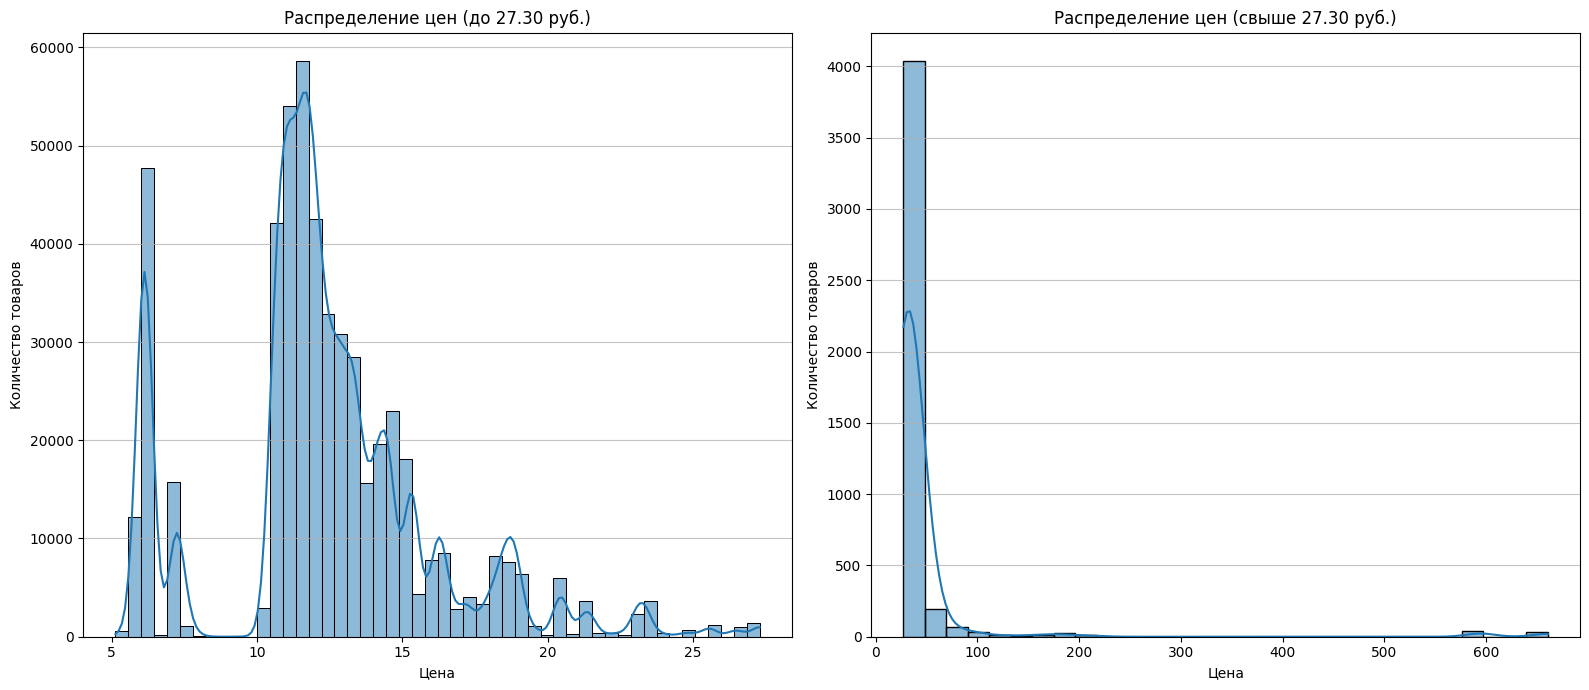

In [55]:

# Гистограмма распределения цен
price_99th_percentile = df['Price'].quantile(0.99)

plt.figure(figsize=(16, 7)) # Increased figure size for better readability

# Подграфик для большинства цен (до 99-го перцентиля)
plt.subplot(1, 2, 1)
sns.histplot(df[df['Price'] <= price_99th_percentile]['Price'], bins=50, kde=True)
plt.title(f'Распределение цен (до {price_99th_percentile:.2f} руб.)')
plt.xlabel('Цена')
plt.ylabel('Количество товаров')
plt.grid(axis='y', alpha=0.75)

# Подграфик для цен выше 99-го перцентиля (длинный хвост)
plt.subplot(1, 2, 2)
sns.histplot(df[df['Price'] > price_99th_percentile]['Price'], bins=30, kde=True)
plt.title(f'Распределение цен (свыше {price_99th_percentile:.2f} руб.)')
plt.xlabel('Цена')
plt.ylabel('Количество товаров')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## **Шаг 2.5. Анализ корзины**

- Среднее количество товаров в заказе
- Средний чек
- Распределение заказов по сумме

In [56]:
# ============================================
# 2.5.1 СРЕДНЕЕ КОЛИЧЕСТВО ТОВАРОВ В ЗАКАЗЕ
# ============================================

avg_quantity = order_agg['total_quantity'].mean()
median_quantity = order_agg['total_quantity'].median()

print("=" * 60)
print("СРЕДНЕЕ КОЛИЧЕСТВО ТОВАРОВ В ЗАКАЗЕ")
print("=" * 60)
print(f"Среднее: {avg_quantity:,.2f} шт.")
print(f"Медиана: {median_quantity:,.2f} шт.")
print("=" * 60)

СРЕДНЕЕ КОЛИЧЕСТВО ТОВАРОВ В ЗАКАЗЕ
Среднее: 228.64 шт.
Медиана: 120.00 шт.


In [57]:
# ============================================
# 2.5.2 СРЕДНИЙ ЧЕК
# ============================================

avg_check = order_agg['total_amount'].mean()
median_check = order_agg['total_amount'].median()

print("=" * 60)
print("СРЕДНИЙ ЧЕК")
print("=" * 60)
print(f"Средний чек: {avg_check:,.2f} руб.")
print(f"Медианный чек: {median_check:,.2f} руб.")
print("=" * 60)

СРЕДНИЙ ЧЕК
Средний чек: 2,590.79 руб.
Медианный чек: 1,377.59 руб.


----
---
---

In [58]:
# ============================================
# 2.5.3 РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО СУММЕ
# ============================================

total = order_agg['total_amount']

# 1. Квантили
quantiles = total.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

print("=" * 60)
print("РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО СУММЕ")
print("=" * 60)

print(f"Минимум:        {total.min():>12,.2f} руб.")
print(f"25-й перцентиль: {quantiles[0.25]:>12,.2f} руб.")
print(f"Медиана:         {quantiles[0.5]:>12,.2f} руб.")
print(f"75-й перцентиль: {quantiles[0.75]:>12,.2f} руб.")
print(f"90-й перцентиль: {quantiles[0.90]:>12,.2f} руб.")
print(f"95-й перцентиль: {quantiles[0.95]:>12,.2f} руб.")
print(f"99-й перцентиль: {quantiles[0.99]:>12,.2f} руб.")
print(f"Максимум:       {total.max():>12,.2f} руб.")
print("=" * 60)

РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО СУММЕ
Минимум:         -840,113.80 руб.
25-й перцентиль:       398.83 руб.
Медиана:             1,377.59 руб.
75-й перцентиль:     2,904.44 руб.
90-й перцентиль:     5,462.59 руб.
95-й перцентиль:     8,177.47 руб.
99-й перцентиль:    22,946.65 руб.
Максимум:       1,002,718.10 руб.


In [59]:
# ============================================
# 2.5.4 РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО ГРУППАМ СУММ
# ============================================

bins = [0, 500, 1000, 2000, 5000, float('inf')]
labels = ['до 500', '500–1000', '1000–2000', '2000–5000', 'более 5000']

order_agg['amount_group'] = pd.cut(
    order_agg['total_amount'],
    bins=bins,
    labels=labels,
    right=False
)

group_counts = order_agg['amount_group'].value_counts().sort_index()
group_percents = (group_counts / len(order_agg) * 100).round(1)

print("=" * 60)
print("РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ СУММ")
print("=" * 60)

for label in labels:
    count = group_counts[label]
    pct = group_percents[label]
    print(f"{label:>14}: {count:>6} заказов ({pct:>5.1f}%)")

print("=" * 60)

РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ СУММ
        до 500:   2959 заказов ( 12.8%)
      500–1000:   3083 заказов ( 13.3%)
     1000–2000:   5085 заказов ( 21.9%)
     2000–5000:   5998 заказов ( 25.8%)
    более 5000:   2665 заказов ( 11.5%)


## **Выводы этапа 2**

На этом этапе данные были подготовлены к углубленному анализу путем создания новых признаков и агрегации информации на уровне заказа.

 **1. Создание новых признаков:**
*   Из колонки `Date` были извлечены `Year`, `Month`, `DayOfWeek` и `DayOfWeekName` для анализа временных трендов и сезонности.
*   Рассчитан признак `TotalAmount` (`Price` × `Quantity`), который учитывает полную стоимость каждой позиции в заказе. Было отмечено наличие отрицательных значений, связанных с возвратами.

**2. Агрегация данных на уровне заказа:**
*   Все транзакции были агрегированы в таблицу `order_agg`, содержащую 23 204 уникальных заказа.
*   Для каждого заказа были рассчитаны: `total_amount` (общая сумма заказа), `total_quantity` (общее количество товаров в заказе) и `unique_products` (количество уникальных товаров).
*   В `order_agg` также были добавлены `customer_no`, `country` и временные признаки для последующего анализа.

**3. Расчёт общих метрик:**
*   **Общая выручка:** 60.12 млн руб.
*   **Всего заказов:** 23 204.
*   **Всего клиентов:** 4 739.
*   **Средний чек:** 2 590.79 руб. (медианный: 1 377.59 руб.). Значительная разница между средним и медианным чеком указывает на влияние крупных заказов.
*   **Средний размер корзины:** 228.64 шт. (медианный: 120 шт.). Аналогично, разница говорит о наличии как мелких, так и крупных оптовых заказов.

 **4. Анализ товаров:**
*   Были определены **Топ-10 товаров по выручке** и **Топ-10 товаров по количеству продаж**.
*   Анализ **распределения цен** выявил, что большинство товаров находятся в низком ценовом сегменте, но существует «длинный хвост» из небольшого числа дорогих товаров. Это было визуализировано с помощью двух гистограмм для лучшего понимания распределения.

**5. Анализ корзины:**
*   Были изучены среднее количество товаров в заказе и средний чек.
*   **Распределение заказов по сумме** было проанализировано с использованием перцентилей и группировки по диапазонам сумм. Было выявлено, что наибольшая доля заказов приходится на суммы от 1000 до 5000 рублей, что указывает на преобладание среднего и выше среднего ценового сегмента в транзакциях.


Этап успешно подготовил данные, создав необходимые признаки и агрегации, а также предоставил первые ключевые инсайты о структуре продаж и поведении клиентов, которые будут развиты в следующем этапе EDA.

---
---
---

**Слабые стороны**

- Отрицательные значения в TotalAmount	Есть возвраты, но они не исключены из order_agg	Для анализа продаж лучше использовать sales_df


- Нет визуализации корзины	Распределение заказов по сумме есть, но без графика	Добавить гистограмму распределения


- Нет анализа по месяцам	Признак Month создан, но не использован	Перенести на этап 3


- Нет клиентского анализа	RFM, топы, новые/повторные — на этапе 3	Перенести на этап 3

---
---
---

# **Этап 3. Исследовательский анализ данных (EDA)**

**Цель этапа**  

Визуальный анализ подготовленных данных для обнаружения скрытых закономерностей, сезонных паттернов и динамики роста/снижения продаж.

Анализ выполняется по направлениям:

- динамика продаж
- товарная структура
- клиентская сегментация
- географическое распределение
- ценовые сегменты

Выявленные закономерности служат основой для определения точек роста и зон просадки, а также для принятия обоснованных бизнес-решений.

---



## **Шаг 3.1. Динамика продаж**

-
-
-



### **Динамика выручки по месяцам**


---


### **Количество заказов по месяцам**



### **Сезонность: сравнение месяцев**




### **Динамика по дням недели**



### **Выводы по шагу 3.1**


## **Шаг 3.2. Анализ товаров**

-
-
-


### **Топ-10 товаров по выручке**




### **Топ-10 товаров по количеству продаж**



### **Распределение цен на товары**



### **Выводы по шагу 3.2**

-
-
-

---

## **Шаг 3.3. Анализ корзины**



### **Средний размер корзины**




### **Средний чек**



### **Распределение заказов по сумме**



### **Выводы по шагу 3.3**

-

-

-

---


## **Шаг 3.4. Анализ клиентов**





### **Новые и повторные клиенты**



### **Выводы по шагу 3.4**

-
-
-
---

## **Шаг 3.5. Географический анализ**




### **Выручка по странам**



### **Количество заказов по странам**



### **Средний чек по странам**



### **Выводы по шагу 3.5**

-
-
-





## **Шаг 3.6. Анализ ценовых сегментов**


---

### **Зависимость количества продаж от цены**




### **Выводы по шагу 3.6**

-
-
-

---
---

## **Выводы этапа 3**

-
-
-

---
---
---

# **Этап 4. Ключевые выводы и рекомендации**
*   Формирование основных инсайтов по каждому блоку анализа.
*   Разработка практических рекомендаций для увеличения выручки, удержания клиентов и оптимизации ассортимента.

## **Итого:**

-
-
-


---
---

## **Рекомендации**

-
-
-

----
----
----